# Linear Regression - Medical Insurance Charges

## Objective

This notebook explores simple linear regression using a healthcare insurance dataset.

### Research Question

Can age be used to predict an individual's medical insurance charges?

### Learning Objectives

- Understand concepts behind linear regression
- Fit a line of best fit
- Understand residuals and sum of squared residuals (SSR)
- Calculate and interpret R^2
- Understand the t-statistic and p-value for the regression slope
- Evaluate the assumptions and limitations of linear regression

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Set up Complete")

Set up Complete


## 01. Dataset & Initial Exploration
### 1.1 Load and Inspect Data

In [ ]:
df = pd.read_csv('insurance.csv')
df.head()
df.info()
df['region'].value_counts()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


There are 1,338 observations with 7 variables each, namely age, sex, bmi, number of children, smoker or not, region, and medical insurance charges. 

### 1.2 Exploring the Relationship between Age and Medical Charges

Text(0, 0.5, 'Medical Charges')

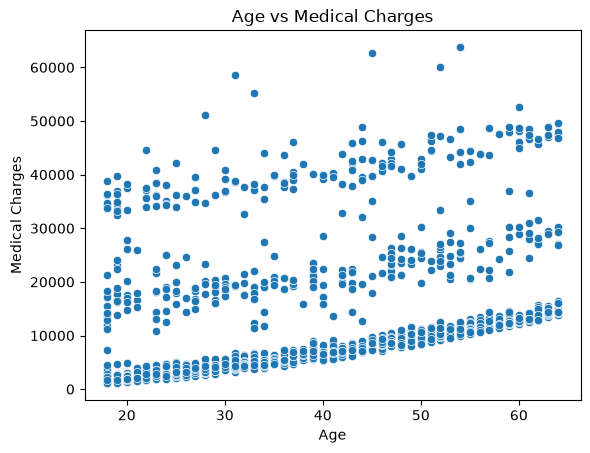

In [48]:
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

## 02. Simple Linear Regression
### 2.1 Fitting a simple Linear Regression Model

Text(0, 0.5, 'Medical Charges')

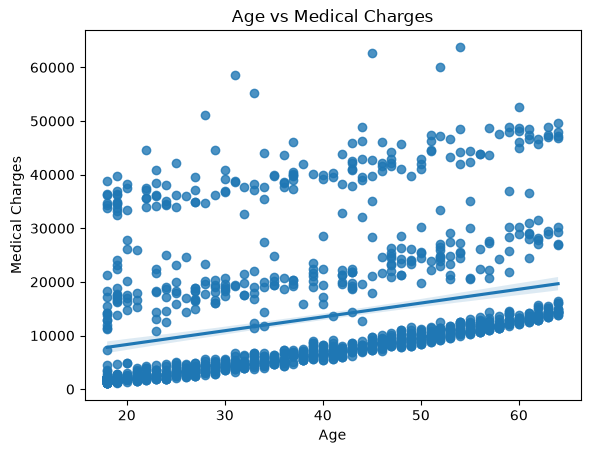

In [49]:
sns.regplot(x='age', y='charges', data=df)
plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")

### 2.2 Regression Equation & Coefficients

In [61]:
import statsmodels.formula.api as smf
#Ordinary least squares to predict charges using age, estimate bestfit coefficients
simple_model = smf.ols(formula='charges ~ age', data=df).fit()
print(simple_model.params)

#Test the model by predicting medical charges for a 40-year-old
age = 40
predicted_charges = simple_model.params['Intercept'] + simple_model.params['age'] * age
print(f"Predicted medical charges for a 40-year-old: ${predicted_charges:.2f}")

#Calculate residuals
df['predicted_charges'] = simple_model.predict(df)
df['residuals'] = df['charges'] - df['predicted_charges']
df[["age", "charges", "predicted_charges", "residuals"]].head()

#Square residuals (SSR(fit))
df["squared_residuals"] = df["residuals"] ** 2
SSR_fit = df["squared_residuals"].sum()
print(f"SSR(fit): {SSR_fit:.2f}")
#Check against Statsmodels
print(f"Statsmodels SSR: {simple_model.ssr:.2f}")

Intercept    3165.885006
age           257.722619
dtype: float64
Predicted medical charges for a 40-year-old: $13474.79
SSR(fit): 178544029385.22
Statsmodels SSR: 178544029385.22


The regression line equation basically means 
Medical charges = (257.72 x age) + 3165.89
It's an upward sloping line where the y-intercept (where age = 0) is $3165.89 with a $257.72 increase with each additional year of age. 

### 2.3 Understanding R^2

In [62]:
# Calculate mean medical charges (for SSR(mean))
mean_charges = df["charges"].mean()
print(f"Mean medical charges: ${mean_charges:.2f}")

#Calculate SSR(mean)
df['SSR_mean'] = (df['charges'] - mean_charges) ** 2
SSR_mean = df['SSR_mean'].sum()
print(f"SSR(mean): {SSR_mean:.2f}")

#Calculate R-squared
print(f"SSR(fit): {SSR_fit:.2f}")
r_squared = 1 - (SSR_fit / SSR_mean)
print(f"R-squared: {r_squared:.4f}")


Mean medical charges: $13270.42
SSR(mean): 196074221568.37
SSR(fit): 178544029385.22
R-squared: 0.0894


R^2 = 0.0894 means that age alone explains approximately 8.94% of variation of medical charges in dataset. 

### 2.4 t-statistic

In [64]:
print(simple_model.bse)  # Standard errors of the coefficients (intercept and age)

#Calculate t-statistics for the coefficients ("how many standard errors away from zero is our estimated slope?")
coefficients = simple_model.params['age']
standard_error = simple_model.bse['age']

t_statistic = (coefficients - 0) / standard_error
print(f"t-statistic: {t_statistic:.4f}")
#Check against Statsmodels
print(f"Statsmodels t-statistic: {model.tvalues['age']:.4f}")


Intercept    937.149465
age           22.502389
dtype: float64
t-statistic: 11.4531
Statsmodels t-statistic: 22.0686


### 2.5 p-value and Statistical Significance

In [ ]:
from scipy import stats

df_residual = simple_model.df_resid  # Degrees of freedom for residuals
t_statistic = simple_model.tvalues['age']  # t-statistic for the age coefficient

#Calculate the two-tailed p-value
p_value = 2 * stats.t.sf(abs(t_statistic), df=df_residual)
print(f"Degrees of freedom: {df_residual:.0f}")
print(f"p-value: {p_value:.10f}")


#Check against Statsmodels
print(f"Statsmodels p-value: {simple_model.pvalues['age']:.10f}")

Degrees of freedom: 1336
p-value: 0.0000000000
Statsmodels p-value: 0.0000000000


### 2.6 Interpreting the Simple Linear Regression Model

The equation of the linear regression line is Predicted Medical Charges = (257.72 x Age) + 3165.89. In essence, this equation predicts that starting from $3165.89, for each additional year of age, predicted medical charges increase by approximately $257.72, on average. 

R^2 was calculated to be at 0.0894, showing us that age alone explains only 8.94% of the variation in the medical charges, leaving 91.06%% of the variation unexplained by this simple model. Other variables, such as smoking status, BMI, number of children, and region, may help explaining some of these remaining variation. 

The p-value was extremely small (<0.05), providing strong evidence against the null hypothesis that the population slope for age is 0. Hence, age is statistically significant associated with medical charges, despite only accounting for 8.94% of the variation of medical charges. 

From the scatterplot of Medical Charges against Age, 3 distinct bands appears to be present, suggesting a different categorical variable may affect medical charges to a greater extent. One plausible factor is the smoking status of the individual. Therefore, we will extend our simple linear regression by including smoking status as an additional predictor.

## 03. Multiple Linear Regression
### 3.1 Fit the Multiple Regression Model
Can we explain medical charges better by considering both age and smoking status?

In [65]:
df['smoker'].value_counts()

#Binary encoding for smoker column
df['smoker_binary'] = df['smoker'].map({'yes': 1, 'no': 0})
df[["smoker", "smoker_binary"]].head()

#Ordinary least squares to predict charges using age and smoker status, estimate bestfit coefficients
#Similar to simple linear regression, but now we add +smoker_binary to the formula
multiple_model = smf.ols("charges ~ age + smoker_binary", data=df).fit()
print(multiple_model.params)

Intercept        -2391.626359
age                274.871186
smoker_binary    23855.304817
dtype: float64


### 3.2 Regression Coefficients
Holding smoking status constant, each additional year of age is associated with an increase of approximately $274.87 in predicted medical charges on average. 

Hoding age constant, smokers have predicted medical charges of approximately $23855.30 higher than non-smokers on average.

In [66]:
#Test the model by predicting medical charges for a 40-year-old smoker and a 40-year-old non-smoker
age = 40
smoker_status = 1  # 1 for smoker, 0 for non-smoker
predicted_charges = multiple_model.params['Intercept'] + multiple_model.params['age'] * age + multiple_model.params['smoker_binary'] * smoker_status
print(f"Predicted medical charges for a 40-year-old smoker: ${predicted_charges:.2f}")
smoker_status = 0  # 0 for non-smoker
predicted_charges = multiple_model.params['Intercept'] + multiple_model.params['age'] * age + multiple_model.params['smoker_binary'] * smoker_status
print(f"Predicted medical charges for a 40-year-old non-smoker: ${predicted_charges:.2f}")

#Use statsmodels to verify predicted medical charges
new_data = pd.DataFrame({'age': [40, 40], 'smoker_binary': [1, 0]})
new_data
statsmodels_predictions = multiple_model.predict(new_data)
print(f"Statsmodels predicted medical charges for a 40-year-old smoker: ${statsmodels_predictions[0]:.2f}")
print(f"Statsmodels predicted medical charges for a 40-year-old non-smoker: ${statsmodels_predictions[1]:.2f}")


Predicted medical charges for a 40-year-old smoker: $32458.53
Predicted medical charges for a 40-year-old non-smoker: $8603.22
Statsmodels predicted medical charges for a 40-year-old smoker: $32458.53
Statsmodels predicted medical charges for a 40-year-old non-smoker: $8603.22


### 3.3 R^2 & Adjusted R^2

In [68]:
#Calculate R-squared for both models
print(f"Simple regression R²: {simple_model.rsquared:.4f}")
print(f"Multiple regression R²: {multiple_model.rsquared:.4f}")

#Calculate adjusted R-squared for both models
print(f"Simple regression adjusted R²: {simple_model.rsquared_adj:.4f}")
print(f"Multiple regression adjusted R²: {multiple_model.rsquared_adj:.4f}")

Simple regression R²: 0.0894
Multiple regression R²: 0.7214
Simple regression adjusted R²: 0.0887
Multiple regression adjusted R²: 0.7210


Adding smoking status to a model that already contains age increases the R^2 value from 0.0894 to 0.7214, indicating that the model explains substantially more variation when smoking status is included. 
The adjusted R^2 values also show that adding the smoking status improves the model well enough to justify its inclusion, even after accounting for the additional complexities involved. (R^2 ALWAYS increases after adding predictors, even if the predictor is a useless variable. Adjusted R^2 accounts for that.)

### 3.4 t-statistic

In [78]:
#Coefficients of multiple regression model
multiple_model.params

#Standard errors of each coefficient
multiple_model.bse

#Manually calculate t-statistic for coefficients
manual_tstat = (multiple_model.params - 0) / multiple_model.bse
print("Manual t-statistics for coefficients:")
print(manual_tstat) 

#Verify against Statsmodels t-statistics
print("Statsmodels t-statistics for coefficients:")
print(multiple_model.tvalues)

Manual t-statistics for coefficients:
Intercept        -4.527005
age              22.068587
smoker_binary    55.031014
dtype: float64
Statsmodels t-statistics for coefficients:
Intercept        -4.527005
age              22.068587
smoker_binary    55.031014
dtype: float64


### 3.5 p-values

In [87]:
#Calculate residual degrees of freedom for multiple regression model
df_residual_multiple = multiple_model.df_resid
print(f"Residual degrees of freedom for multiple regression model: {df_residual_multiple:.0f}")

#Manually calculate p-values for coefficients
pvalue_age = 2 * stats.t.sf(abs(multiple_model.tvalues['age']), df=df_residual_multiple)
pvalue_smoker = 2 * stats.t.sf(abs(multiple_model.tvalues['smoker_binary']), df=df_residual_multiple)
print(f"Manual p-value for age coefficient: {pvalue_age:.10f}")
print(f"Manual p-value for smoker_binary coefficient: {pvalue_smoker:.10f}")

#Verify against Statsmodels p-values
print(f"Statsmodels p-value for age coefficient: {multiple_model.pvalues['age']:.10f}")
print(f"Statsmodels p-value for smoker_binary coefficient: {multiple_model.pvalues['smoker_binary']:.10f}")

Residual degrees of freedom for multiple regression model: 1335
Manual p-value for age coefficient: 0.0000000000
Manual p-value for smoker_binary coefficient: 0.0000000000
Statsmodels p-value for age coefficient: 0.0000000000
Statsmodels p-value for smoker_binary coefficient: 0.0000000000


### 3.6 Interpretation & Limitations

The multiple regression model equation is calculated to be Predicted Charges = (274.87 x Age) + (23855.30 x Smoker) - 2391.63, where smoker = 1 and non-smoker = 0. 

Holding smoking status constant, each additional year of age is associated with an estimated $274.87 increase in predicted medical charges on average. p-value for age is extremely small (<0.001), indicating that age remains statistically significant associated with medical charges, even after accounting for smoking status. 

Holding age constant, smokers have predicted medical charges of approximately $23855.30 higher than non-smokers on average. p-value for smoking status is also extremely small (<0.001), indicating that smoking status is statistically significantly associated with medical charges, accounting for age.

Age alone explained 8.94% (R^2 of simple linear regression = 0.0894) of the variation in medical charges, while age and smoking status explained 72.14% (R^2 of multiple linear regression = 0.7214).

Given the large coefficient (23855.30), large t-statistic (55.03), extremely low p-value (<0.001), and significant increase of R^2 from 8.94% to 72.14% of smoking status, adding smoking status dramatically improved the explanatory power of the model. This supports the initial observation from the scatterplot that apparent bands in medical charges may be associated with smoking status. 

## 04. Two-Sample t-test
### 4.1 Define the Two Groups
Are the mean medical charges of smokers and non-smokers significantly different?

In [93]:
non_smoker_charges = df[df["smoker"] == "no"]["charges"]
smoker_charges = df[df["smoker"] == "yes"]["charges"]

print(f"Non-smoker mean charges: ${non_smoker_charges.mean():,.2f}")
print(f"Smoker mean charges: ${smoker_charges.mean():,.2f}")

Non-smoker mean charges: $8,434.27
Smoker mean charges: $32,050.23


### 4.2 Compare Group Means

In [94]:
mean_difference = smoker_charges.mean() - non_smoker_charges.mean()

print(f"Difference in mean charges: ${mean_difference:,.2f}")

Difference in mean charges: $23,615.96


### 4.3 t-statistic

In [102]:
#Calculate variance of charges for smokers and non-smokers
print(f"Smoker variance: {smoker_charges.var():,.2f}")
print(f"Non-smoker variance: {non_smoker_charges.var():,.2f}")
#Calculate sample sizes for smokers and non-smokers
print(f"Smoker sample size: {len(smoker_charges)}")
print(f"Non-smoker sample size: {len(non_smoker_charges)}")

#Manually calculate t-statistic for difference in means
SE_meandiff = ((smoker_charges.var() / len(smoker_charges)) + (non_smoker_charges.var() / len(non_smoker_charges))) ** 0.5
se_difference = np.sqrt((smoker_charges.var() / len(smoker_charges)) + (non_smoker_charges.var() / len(non_smoker_charges)))
print(f"Standard error of the difference in means: {SE_meandiff:,.2f}")
print(f"Standard error of the difference in means (using np.sqrt): {se_difference:,.2f}")
tstat_meandiff = mean_difference / SE_meandiff
print(f"t-statistic for difference in means: {tstat_meandiff:.4f}")

#Verify t-statistic using scipy.stats.ttest_ind
tstat_scipy, pvalue_scipy = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False) #Use Welch's t-test (do not assume equal variances)
print(f"t-statistic using scipy.stats.ttest_ind: {tstat_scipy:.4f}")


Smoker variance: 133,207,311.21
Non-smoker variance: 35,925,420.50
Smoker sample size: 274
Non-smoker sample size: 1064
Standard error of the difference in means: 721.06
Standard error of the difference in means (using np.sqrt): 721.06
t-statistic for difference in means: 32.7519
t-statistic using scipy.stats.ttest_ind: 32.7519


Since variances and group sizes between smoker and non-smoker groups are very different, we performed Welch's t-test, which does not assume equal variance.

### 4.4 p-value
The p-value tells us how likely it would be to observe a difference in means this large, or larger, if the null hypothesis of equal population means were true.

In [ ]:
#Calculate p-value using scipy.stats.ttest_ind
print(f"p-value using scipy.stats.ttest_ind: {pvalue_scipy:.4f}") #From 4.3

p-value using scipy.stats.ttest_ind: 0.0000


### 4.5 Interpretation & Limitations

The mean medical charges for smokers and non-smokers are $32,050.23 and $8,434.27 respectively. In this sample, smokers had average medical charges approximately $23,616 higher than non-smokers.

The t-statistic for difference in means is 32.7519, provides enormous evidence against the null hypothesis. Simply put, the observed difference in mean charges between smokers and non-smokers is about 32.75 standard errors away from 0.

The p-value is less than 0.001, which is below the significance level of 0.05. Therefore, we reject the null hypothesis and conclude that there is statistically significant evidence that the population mean medical charges differ between smokers and non-smokers.

The limitation of the two-tailed t-test performed is that it compares the groups of smokers vs non-smokers without accounting for the age. Assuming that the smokers in the sample were older on average than non-smokers, some of the observed difference in medical charges could be associated with age rather than smoking status itself. The two-sample t-test does not account for this potentially confounding variable. 

## 05. One-Way ANOVA
### 5.1 Define the Groups
We have 4 groups under the column "region", namely "northeast", "northwest", "southeast", "southwest". 
The question now is whether the mean medical charges different across the 4 regions, and is there evidence that at least 1 group mean differs from the others?

In [ ]:
#Calculate value counts for each region
df.value_counts("region")
#Calculate mean medical charges by region
region_means = df.groupby("region")["charges"].mean()
print("Mean medical charges by region:")
print(region_means)

Mean medical charges by region:
region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


### 5.2 Compare Groups Means

In [108]:
#Calculate overall mean medical charges
overall_mean = df["charges"].mean()
print(f"Overall mean medical charges: ${overall_mean:,.2f}")

Overall mean medical charges: $13,270.42


### 5.3 F-statistic
F = Between-group variation / Within-group variation
Between-group variation answers the question of "How much do the group means differ from one another?"
Within-group variation answer the question of "Among the samples in the each group, how much do they differ from one another?"
With the F-statistic, it answers the question of "How large is the variation between the group means compared with the variation within the groups?"

In [126]:
#Calculate Sum of Squares Between groups (SSB) for ANOVA
#using SSB = sum of (n * (regional_mean - overall_mean)^2) for each group
SSB = 0
for region, group in df.groupby("region"):
    group_mean = group["charges"].mean()
    n = len(group)
    SSB += n * (group_mean - overall_mean) ** 2
print(f"SSB (Between-group): {SSB:.2f}")

#Calculate Sum of Squares Within groups (SSW) for ANOVA
#using SSW = sum of squared differences between each observation and its group mean
SSW = 0
for region, group in df.groupby("region"):
    group_mean = group["charges"].mean()
    group_ssw = ((group["charges"] - group_mean) ** 2).sum()
    SSW += group_ssw
print(f"SSW (Within-group): {SSW:.2f}")

#Calculate degrees of freedom for between and within groups
k = df["region"].nunique()  # Number of groups
N = len(df)  # Total number of observations
df_between = k - 1
df_within = N - k
print(f"Degrees of freedom (between): {df_between}")
print(f"Degrees of freedom (within): {df_within}")

#Calculate Mean Squares for between and within groups
MSB = SSB / df_between #Mean Square Between
MSW = SSW / df_within  #Mean Square Within
print(f"MSB (Mean Square Between): {MSB:.2f}")
print(f"MSW (Mean Square Within): {MSW:.2f}")

#Calculate F-statistic for ANOVA
fstat = MSB / MSW
print(f"Manual F-statistic: {fstat:.4f}")

#Verify F-statistic using scipy.stats.f_oneway
fstat_scipy, pvalue_scipy = stats.f_oneway(df[df["region"] == "northeast"]["charges"],
                                           df[df["region"] == "northwest"]["charges"],
                                           df[df["region"] == "southeast"]["charges"],
                                           df[df["region"] == "southwest"]["charges"])
print(f"SciPy F-statistic: {fstat_scipy:.4f}")

SSB (Between-group): 1300759681.31
SSW (Within-group): 194773461887.06
Degrees of freedom (between): 3
Degrees of freedom (within): 1334
MSB (Mean Square Between): 433586560.44
MSW (Mean Square Within): 146007092.87
Manual F-statistic: 2.9696
SciPy F-statistic: 2.9696


### 5.4 p-value

In [131]:
#Manually calculate p-value for F-statistic using survival function (sf) of the F-distribution
p_value_manual = stats.f.sf(F_statistic, df_between,df_within)
print(f"Manual p-value: {p_value_manual:.5f}")

#Calculate p-value using scipy.stats.f_oneway
print(f"SciPy p-value: {pvalue_scipy:.5f}") #From 5.3

Manual p-value: 0.03089
SciPy p-value: 0.03089


### 5.5 Post-hoc Analysis - Tukey's HSD
Since p < 0.05, we reject the null hypothesis. Therefore, there is statistically significant eivdence that at least 1 regional mean medical charge differs from another.
We will use Tukey's HSD to determine which pairs are different.

In [132]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df["charges"], groups=df["region"], alpha=0.05)
print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
northeast northwest  -988.8091 0.7245 -3428.9343 1451.3161  False
northeast southeast  1329.0269 0.4745 -1044.9417 3702.9955  False
northeast southwest -1059.4471 0.6792 -3499.5723 1380.6781  False
northwest southeast  2317.8361 0.0583   -54.1994 4689.8716  False
northwest southwest    -70.638 0.9999 -2508.8826 2367.6066  False
southeast southwest -2388.4741 0.0477 -4760.5096  -16.4386   True
-----------------------------------------------------------------


### 5.6 Interpretation & Limitations

The F-statistic calculated to be 2.9696, which means that the between-group variation is approximately 2.97 times larger than the within-group variation after accounting for their respective degrees of freedom. Since the p-value is 0.03089 (<0.05), we reject the null hypothesis and conclude that there is evidence that at least 1 regional population mean differs from the others. 

From the Tukey's HSD result, only the Southeast vs Southwest regional means were statistically significantly different. The Southeast had significantly higher mean medical charges than the Southwest, with an adjusted p-value of 0.047. 

Limitations of the ANOVA is that it compares groups without accounting for other variables such as age, smoking status, BMI, and more. Differences in these variables could contribute to the observed differences in medical charges. Therefore, the observed association between region and medical charges should not be interpreted as a causal relationship.

## 06. Connecting the Concepts
### Linear Regression vs Multiple Regression

Simple Linear Regression - 1 predictor (Age)
Multiple Linear Regression >=2 predictors (Age, Smoking status)
Simple linear regression considers one predictor while multiple linear regression considers multiple predictors simultaneously. Adding smoking status substantially increased the model's explanatory power from 8.94% to 72.14%.

### Regression vs t-test

A binary categorical variable like smoking status (yes or no) can be incorporated into a linear regression model as a binary predictor (1/0). Therefore, a two-group t-test and a linear regression with a binary predictor are closely related statistical approaches, although regression gives us the ability to incorporate additional predictors such as age. 

t-test answered the question of whether the mean charges of smokers and non-smokers are different, while multiple regression answered the question of how much higher are the predicted charges for smokers as compared to non-smokers, while holding age constant.

### What the different statistics are telling us
Coefficient - Size and direction of a predictor's effect
Residual - Difference between observed and predicted values
SSR - Sum of squared variation around the model
R^2 - Proportion of outcome variation explained by the model
Adjusted R^2 - R^2 adjusted for the number of predictors
t-statistic - How many standard errors an estimated effect is from the null value
p-value - Evidence against null hypothesis
F-statistic - Ratio of between-group/model variation to within-group/error variation
ANOVA p-value - Whether there is evidence that at least one group mean differs
Tukey HSD - Which specific group pairs differ after ANOVA

## Key takeaways
Across this notebook, I explored simple linear regression, multiple linear regression, t-test and ANOVA using the same healthcare dataset. Although each statistical method appears to be different techniques, they are closely connected through the concepts of variance, estimated effects, standard errors, test statistics, and p-values.

One key lesson from this notebook is that statistical significance and explanatory powers are different concepts. For example, age was statistically significant in the simple linear regression model but only explained 8.94% of the variation in medical charges. 

These methods provide a foundation for learning and understanding statistical inference and will be useful when moving into machine learning models.